# Spam Email Classifier — Final Merged Version
> All improvements documented with `[FIX]`, `[IMPROVE]`, or `[NEW]`

## 1. Imports

In [7]:
# [FIX] All imports consolidated in one cell — no scattered imports across notebook
# [FIX] Removed unused LinearRegression import
import re
import joblib
import numpy as np
import pandas as pd
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV   # [NEW] required for SVM probabilities
from sklearn.ensemble import GradientBoostingClassifier   # [NEW] used in leakage audit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from scipy.sparse import hstack, csr_matrix

from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import (
    Layer, Input, Embedding, LSTM,
    Dense, Bidirectional, Dropout, Concatenate
)
from tensorflow.keras.models import Model
import tensorflow.keras.backend as K



## 2. Load & Exploratory Data Analysis

In [8]:
data = pd.read_csv(r"spam_email_dataset.csv")
print(f"Dataset shape: {data.shape}")
print(f"Duplicates: {data.duplicated().sum()}")
print(f"Missing values:\n{data.isna().sum()}")
print(f"\nLabel distribution:\n{data['label'].value_counts()}")
data.head()

Dataset shape: (10000, 20)
Duplicates: 0
Missing values:
email_id                   0
subject                    0
email_text                 0
num_words                  0
num_characters             0
num_exclamation_marks      0
num_links                  0
has_suspicious_link        0
num_attachments            0
has_attachment             0
sender_email               0
sender_domain              0
sender_reputation_score    0
email_hour                 0
email_day_of_week          0
is_weekend                 0
num_recipients             0
contains_money_terms       0
contains_urgency_terms     0
label                      0
dtype: int64

Label distribution:
label
0    6005
1    3995
Name: count, dtype: int64


,email_id,subject,email_text,num_words,num_characters,num_exclamation_marks,num_links,has_suspicious_link,num_attachments,has_attachment,sender_email,sender_domain,sender_reputation_score,email_hour,email_day_of_week,is_weekend,num_recipients,contains_money_terms,contains_urgency_terms,label
0,0,Weekly Report,budget review - Statement our I claim world st...,19,114,0,2,0,2,1,lctvdzm@outlook.com,outlook.com,0.66,19,3,0,23,0,0,0
1,1,Project Update,team sync - President series today already. In...,18,114,0,7,0,0,0,pxyldmi@company.com,company.com,0.95,4,4,0,16,1,0,0
2,2,🔥WIN BIG NOW!!,win free urgent offer limited limited urgent u...,19,126,0,4,1,1,1,atvanls@unknownmail.cc,unknownmail.cc,0.68,3,0,0,10,1,1,1
3,3,🔥WIN BIG NOW!!,guarantee click now cash offer click now guara...,16,101,0,7,1,1,1,qalxcnf@chealdealz.xyz,chealdealz.xyz,0.69,19,5,1,25,1,1,1
4,4,Meeting Reminder,team sync - Significant property hotel not add...,18,111,0,7,1,2,1,xoiccxl@yahoo.com,yahoo.com,0.67,4,5,1,8,0,0,0


Correlation coefficient:
                num_words  num_characters
num_words        1.000000        0.969111
num_characters   0.969111        1.000000


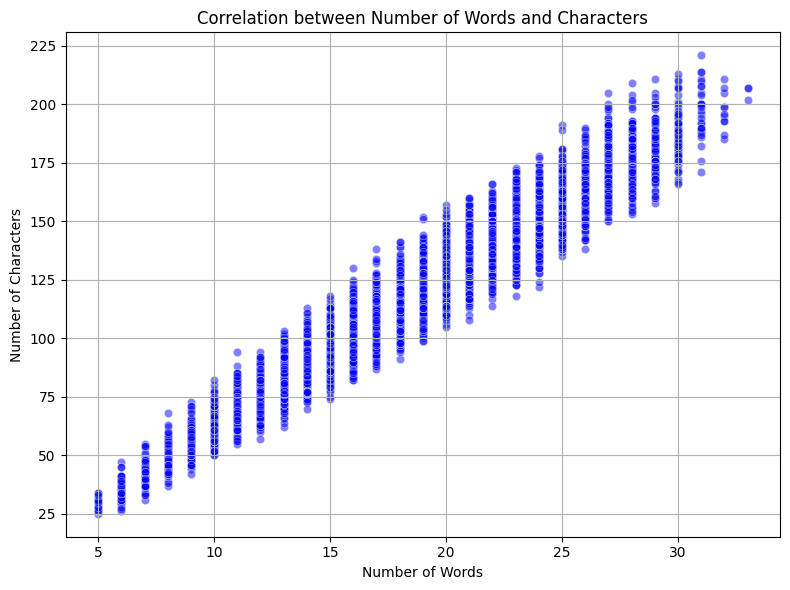

In [9]:
# Correlation analysis: num_words vs num_characters
# [NOTE] Correlation is ~0.97 → dropping num_characters is justified to avoid redundancy
correlation = data[['num_words', 'num_characters']].corr()
print(f"Correlation coefficient:\n{correlation}")

plt.figure(figsize=(8, 6))
sns.scatterplot(x='num_words', y='num_characters', data=data, color='blue', alpha=0.5)
plt.title('Correlation between Number of Words and Characters')
plt.xlabel('Number of Words')
plt.ylabel('Number of Characters')
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. Feature Leakage Audit (NEW)
Run this **before** training. If metadata-only accuracy exceeds 90%, the dataset has leakage
and reported model accuracy will be inflated.

In [10]:
leakage_cols = [
    'contains_money_terms', 'contains_urgency_terms',
    'has_suspicious_link', 'sender_reputation_score',
    'num_recipients'
]
X_leak = data[leakage_cols]
y_leak = data['label']

Xl_tr, Xl_te, yl_tr, yl_te = train_test_split(
    X_leak, y_leak, test_size=0.2, random_state=42, stratify=y_leak
)
leak_model = GradientBoostingClassifier(n_estimators=50, random_state=42)
leak_model.fit(Xl_tr, yl_tr)
leak_acc = accuracy_score(yl_te, leak_model.predict(Xl_te))

print("=" * 55)
print(f"  Metadata-ONLY accuracy (leakage proxy): {leak_acc:.4f}")
if leak_acc > 0.90:
    print("  ⚠  HIGH LEAKAGE — metadata columns already encode the label.")
    print("     Take overall model accuracy with caution.")
elif leak_acc > 0.75:
    print("  ⚠  MODERATE LEAKAGE — some inflation is likely.")
else:
    print("  ✓  LOW LEAKAGE — metadata adds signal but does not trivially predict the label.")
print("=" * 55)

  Metadata-ONLY accuracy (leakage proxy): 0.8515
  ⚠  MODERATE LEAKAGE — some inflation is likely.


## 4. Text Preprocessing

In [11]:
# [FIX] Document the reason for each column dropped:
# - email_id          : sequential ID, no predictive value
# - sender_email      : domain already extracted as sender_domain
# - has_attachment    : redundant with num_attachments
# - num_characters    : correlation 0.97 with num_words → redundant
# - num_exclamation_marks : std = 0 (all zeros) → dead feature
data.drop(
    columns=["email_id", "sender_email", "has_attachment",
             "num_characters", "num_exclamation_marks"],
    inplace=True
)
print("Remaining columns:", data.columns.tolist())

Remaining columns: ['subject', 'email_text', 'num_words', 'num_links', 'has_suspicious_link', 'num_attachments', 'sender_domain', 'sender_reputation_score', 'email_hour', 'email_day_of_week', 'is_weekend', 'num_recipients', 'contains_money_terms', 'contains_urgency_terms', 'label']


In [12]:
# Download NLTK resources (run once)
for pkg in ['punkt', 'stopwords', 'wordnet', 'averaged_perceptron_tagger_eng', 'omw-1.4']:
    nltk.download(pkg, quiet=True)

lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

In [13]:
# Combine subject + email body into a single text field
data['full_text'] = data['subject'].fillna('') + " " + data['email_text'].fillna('')
print(data[['subject', 'email_text', 'full_text']].head())

            subject                                         email_text  \
0     Weekly Report  budget review - Statement our I claim world st...   
1    Project Update  team sync - President series today already. In...   
2    🔥WIN BIG NOW!!  win free urgent offer limited limited urgent u...   
3    🔥WIN BIG NOW!!  guarantee click now cash offer click now guara...   
4  Meeting Reminder  team sync - Significant property hotel not add...   

                                           full_text  
0  Weekly Report budget review - Statement our I ...  
1  Project Update team sync - President series to...  
2  🔥WIN BIG NOW!! win free urgent offer limited l...  
3  🔥WIN BIG NOW!! guarantee click now cash offer ...  
4  Meeting Reminder team sync - Significant prope...  


In [14]:
def get_wordnet_pos(treebank_tag: str) -> str:
    """Map NLTK POS tag to WordNet POS for more accurate lemmatization."""
    mapping = {'J': wordnet.ADJ, 'V': wordnet.VERB,
               'N': wordnet.NOUN, 'R': wordnet.ADV}
    return mapping.get(treebank_tag[0], wordnet.NOUN)


def preprocess_text(text: str) -> str:
    """Clean and normalize text with POS-aware lemmatization."""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)   # remove punctuation
    text = re.sub(r'\d+', ' ', text)         # [IMPROVE] remove digits — no linguistic value
    words = text.split()
    pos_tags = nltk.pos_tag(words)
    return ' '.join(
        lemmatizer.lemmatize(word, pos=get_wordnet_pos(tag))
        for word, tag in pos_tags
        if word not in stop_words and len(word) > 1  # [IMPROVE] drop single-char tokens
    )


print("Processing texts… (may take a few minutes)")
data['clean_text'] = data['full_text'].apply(preprocess_text)
print(data[['full_text', 'clean_text']].head())

Processing texts… (may take a few minutes)
                                           full_text  \
0  Weekly Report budget review - Statement our I ...   
1  Project Update team sync - President series to...   
2  🔥WIN BIG NOW!! win free urgent offer limited l...   
3  🔥WIN BIG NOW!! guarantee click now cash offer ...   
4  Meeting Reminder team sync - Significant prope...   

                                          clean_text  
0  weekly report budget review statement claim wo...  
1  project update team sync president series toda...  
2  win big win free urgent offer limit limited ur...  
3  win big guarantee click cash offer click guara...  
4  meet reminder team sync significant property h...  


In [15]:
# Drop raw text columns after clean_text is ready
data.drop(columns=['subject', 'email_text', 'full_text'], inplace=True)
print("Final columns:")
print(data.info())

Final columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   num_words                10000 non-null  int64  
 1   num_links                10000 non-null  int64  
 2   has_suspicious_link      10000 non-null  int64  
 3   num_attachments          10000 non-null  int64  
 4   sender_domain            10000 non-null  object 
 5   sender_reputation_score  10000 non-null  float64
 6   email_hour               10000 non-null  int64  
 7   email_day_of_week        10000 non-null  int64  
 8   is_weekend               10000 non-null  int64  
 9   num_recipients           10000 non-null  int64  
 10  contains_money_terms     10000 non-null  int64  
 11  contains_urgency_terms   10000 non-null  int64  
 12  label                    10000 non-null  int64  
 13  clean_text               10000 non-null  object 
dtypes: float

## 5. Feature Engineering

In [16]:
# [FIX] Encode sender_domain instead of dropping it — carries meaningful signal
le = LabelEncoder()
data['sender_domain_encoded'] = le.fit_transform(data['sender_domain'])
data.drop(columns=['sender_domain'], inplace=True)

X_text    = data['clean_text']
X_numeric = data.drop(columns=['clean_text', 'label'])
y         = data['label']

print(f"Numeric features ({X_numeric.shape[1]}): {X_numeric.columns.tolist()}")

Numeric features (12): ['num_words', 'num_links', 'has_suspicious_link', 'num_attachments', 'sender_reputation_score', 'email_hour', 'email_day_of_week', 'is_weekend', 'num_recipients', 'contains_money_terms', 'contains_urgency_terms', 'sender_domain_encoded']


## 6. Train / Test Split

In [17]:
# Split text and numeric arrays together to preserve alignment
X_text_train, X_text_test, X_num_train, X_num_test, y_train, y_test = train_test_split(
    X_text, X_numeric, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # [IMPROVE] ensures balanced label distribution in both splits
)
print(f"Train: {len(y_train)}  |  Test: {len(y_test)}")
print(f"y_train distribution:\n{y_train.value_counts()}")

Train: 8000  |  Test: 2000
y_train distribution:
label
0    4804
1    3196
Name: count, dtype: int64


## 7. Encode sender_domain on Split Sets

In [18]:
# Apply LabelEncoder fitted on training split only — avoids leakage
le_split = LabelEncoder()
X_num_train = X_num_train.copy()
X_num_test  = X_num_test.copy()

X_num_train['sender_domain_encoded'] = le_split.fit_transform(X_num_train['sender_domain']) \
    if 'sender_domain' in X_num_train.columns else X_num_train.get('sender_domain_encoded', 0)

le_dict = dict(zip(le_split.classes_, le_split.transform(le_split.classes_))) \
    if 'sender_domain' in X_num_train.columns else {}

if 'sender_domain' in X_num_test.columns:
    X_num_test['sender_domain_encoded'] = X_num_test['sender_domain'].apply(
        lambda x: le_dict.get(x, -1)
    )
    X_num_train.drop(columns=['sender_domain'], inplace=True)
    X_num_test.drop(columns=['sender_domain'], inplace=True)

# [NEW] Save the exact feature order so app.py can reproduce the same columns
NUMERIC_FEATURE_NAMES = X_num_train.columns.tolist()
print("Numeric feature order:", NUMERIC_FEATURE_NAMES)

Numeric feature order: ['num_words', 'num_links', 'has_suspicious_link', 'num_attachments', 'sender_reputation_score', 'email_hour', 'email_day_of_week', 'is_weekend', 'num_recipients', 'contains_money_terms', 'contains_urgency_terms', 'sender_domain_encoded']


## 8. Vectorize Text + Scale Numeric Features

In [19]:
# [IMPROVE] ngram_range=(1,2) captures bigrams like "free money" — stronger signal
# [IMPROVE] min_df=2 keeps rare but potentially informative terms
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=2)
X_text_train_tfidf = tfidf.fit_transform(X_text_train)
X_text_test_tfidf  = tfidf.transform(X_text_test)

scaler = StandardScaler()
X_num_train_scaled = scaler.fit_transform(X_num_train)
X_num_test_scaled  = scaler.transform(X_num_test)

# [IMPROVE] Explicit csr_matrix conversion for better XGBoost performance
X_train_combined = csr_matrix(hstack((X_text_train_tfidf, X_num_train_scaled)))
X_test_combined  = csr_matrix(hstack((X_text_test_tfidf,  X_num_test_scaled)))

print(f"Train shape: {X_train_combined.shape}  |  Test shape: {X_test_combined.shape}")

Train shape: (8000, 3012)  |  Test shape: (2000, 3012)


## 9. Model 1 — Linear SVM
**[FIX]** Wrapped with `CalibratedClassifierCV` so the app receives real probabilities
instead of the useless *"N/A (Linear SVM Boundary Metric)"* label.

In [20]:
print("--- Linear SVM ---")
base_svm  = LinearSVC(random_state=42, max_iter=2000)  # [IMPROVE] raised max_iter for convergence
svm_model = CalibratedClassifierCV(base_svm, cv=5)     # [FIX] calibrated wrapper for probabilities
svm_model.fit(X_train_combined, y_train)
svm_predictions = svm_model.predict(X_test_combined)
print(classification_report(y_test, svm_predictions))
print("Accuracy:", accuracy_score(y_test, svm_predictions))

# Cross-validation on base estimator (faster; calibration wrapper not needed here)
svm_cv = cross_val_score(
    LinearSVC(random_state=42, max_iter=2000),
    X_train_combined, y_train, cv=5, scoring='f1'
)
print(f"Cross-Val F1 (SVM): {svm_cv.mean():.4f} ± {svm_cv.std():.4f}")

--- Linear SVM ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1201
           1       1.00      1.00      1.00       799

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Accuracy: 1.0
Cross-Val F1 (SVM): 1.0000 ± 0.0000


## 10. Model 2 — XGBoost

In [21]:
print("--- XGBoost ---")
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    # [FIX] removed deprecated use_label_encoder parameter
    eval_metric='logloss',
    tree_method='hist'   # [IMPROVE] faster with sparse matrices
)
xgb_model.fit(X_train_combined, y_train)
xgb_predictions = xgb_model.predict(X_test_combined)
print(classification_report(y_test, xgb_predictions))
print("Accuracy:", accuracy_score(y_test, xgb_predictions))

xgb_cv = cross_val_score(
    XGBClassifier(n_estimators=100, learning_rate=0.1,
                  random_state=42, eval_metric='logloss', tree_method='hist'),
    X_train_combined, y_train, cv=5, scoring='f1'
)
print(f"Cross-Val F1 (XGBoost): {xgb_cv.mean():.4f} ± {xgb_cv.std():.4f}")

--- XGBoost ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1201
           1       1.00      1.00      1.00       799

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Accuracy: 0.9995
Cross-Val F1 (XGBoost): 0.9998 ± 0.0003


## 11. Model 3 — Bidirectional LSTM with Attention
Hybrid model combining text sequences (via BiLSTM + Attention) with numeric features.

In [22]:
MAX_VOCAB_SIZE       = 5000
MAX_SEQUENCE_LENGTH = 150

dl_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
dl_tokenizer.fit_on_texts(X_text_train)

X_train_pad = pad_sequences(
    dl_tokenizer.texts_to_sequences(X_text_train),
    maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post'
)
X_test_pad = pad_sequences(
    dl_tokenizer.texts_to_sequences(X_text_test),
    maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post'
)
print(f"Padded train shape: {X_train_pad.shape}  |  test shape: {X_test_pad.shape}")

Padded train shape: (8000, 150)  |  test shape: (2000, 150)


In [23]:
class AttentionLayer(Layer):
    """Soft attention over BiLSTM hidden states."""

    def build(self, input_shape):
        # [FIX] Keras 3.x requires keyword-only 'name' argument in add_weight()
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1),
                                  initializer="normal", trainable=True)
        self.b = self.add_weight(name="att_bias",   shape=(input_shape[1],  1),
                                  initializer="zeros",  trainable=True)
        super().build(input_shape)

    def call(self, x):
        e = K.tanh(K.dot(x, self.W) + self.b)
        a = K.softmax(e, axis=1)
        return K.sum(x * a, axis=1)


EMBEDDING_DIM        = 64
NUMERIC_FEATURES_DIM = X_num_train_scaled.shape[1]

# Text branch
text_input    = Input(shape=(MAX_SEQUENCE_LENGTH,), name="text_input")
embedding     = Embedding(MAX_VOCAB_SIZE, EMBEDDING_DIM,
                           input_length=MAX_SEQUENCE_LENGTH)(text_input)
lstm          = Bidirectional(LSTM(64, return_sequences=True))(embedding)
attention_out = AttentionLayer()(lstm)
text_dense    = Dense(32, activation='relu')(attention_out)

# Numeric branch
numeric_input = Input(shape=(NUMERIC_FEATURES_DIM,), name="numeric_input")
numeric_dense = Dense(16, activation='relu')(numeric_input)

# Merge
combined     = Concatenate()([text_dense, numeric_dense])
fc_layer     = Dense(32, activation='relu')(combined)
dropout      = Dropout(0.5)(fc_layer)
output_layer = Dense(1, activation='sigmoid')(dropout)

hybrid_model = Model(inputs=[text_input, numeric_input], outputs=output_layer)
hybrid_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
hybrid_model.summary()

c:\Users\Baina\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 150)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 150, 64)   │    320,000 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 150, 128)  │     66,048 │ embedding[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer     │ (None, 128)       │        278 │ bidirectional[0]… │
│ (AttentionLayer)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_input       │ (None, 12)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      4,128 │ attention_layer[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │        208 │ numeric_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 48)        │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      1,568 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         33 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 392,263 (1.50 MB)

 Trainable params: 392,263 (1.50 MB)

 Non-trainable params: 0 (0.00 B)

## 12. Train Deep Learning Model

In [24]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

history = hybrid_model.fit(
    [X_train_pad, X_num_train_scaled], y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

predictions_prob = hybrid_model.predict([X_test_pad, X_num_test_scaled])
dl_predictions   = (predictions_prob > 0.5).astype(int)
print(classification_report(y_test, dl_predictions))
print("Accuracy:", accuracy_score(y_test, dl_predictions))

Epoch 1/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - accuracy: 0.7284 - loss: 0.4758 - val_accuracy: 1.0000 - val_loss: 4.2187e-06
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 12s 102ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 1.0000 - val_loss: 2.5987e-07
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 8s 72ms/step - accuracy: 1.0000 - loss: 9.4604e-04 - val_accuracy: 1.0000 - val_loss: 3.4291e-08
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - accuracy: 1.0000 - loss: 4.3699e-04 - val_accuracy: 1.0000 - val_loss: 7.1312e-09
Epoch 5/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 1.0000 - loss: 5.0756e-04 - val_accuracy: 1.0000 - val_loss: 1.9236e-09
Epoch 6/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 1.0000 - loss: 3.3582e-04 - val_accuracy: 1.0000 - val_loss: 8.8482e-10
Epoch 7/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.9999 - loss: 3.1594e-04 - val_accuracy: 1.0000 - val_loss: 5.7056e-10
Epoch 8/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms

## 13. Results Summary

In [25]:
results = {
    "Model"     : ["Linear SVM", "XGBoost", "BiLSTM + Attention"],
    "Test Acc"  : [
        accuracy_score(y_test, svm_predictions),
        accuracy_score(y_test, xgb_predictions),
        accuracy_score(y_test, dl_predictions),
    ],
    "CV F1 Mean": [svm_cv.mean(), xgb_cv.mean(), None],
    "CV F1 Std" : [svm_cv.std(),  xgb_cv.std(),  None],
}
print(pd.DataFrame(results).to_string(index=False))

             Model  Test Acc  CV F1 Mean  CV F1 Std
        Linear SVM    1.0000    1.000000   0.000000
           XGBoost    0.9995    0.999843   0.000313
BiLSTM + Attention    1.0000         NaN        NaN


## 14. Save All Models & Pipeline Assets
**[FIX]** Hybrid model saved in `.keras` format (not legacy `.h5`).
**[NEW]** `keras_tokenizer` and `numeric_feature_names` saved so `app.py` never has to
guess column order or rebuild the tokenizer.

In [26]:
joblib.dump(svm_model,             'spam_svm_model.joblib')
joblib.dump(xgb_model,             'spam_xgb_model.joblib')
joblib.dump(tfidf,                 'tfidf_vectorizer.joblib')
joblib.dump(scaler,                'scaler.joblib')
joblib.dump(le,                    'label_encoder.joblib')
joblib.dump(dl_tokenizer,          'keras_tokenizer.joblib')          # [NEW]
joblib.dump(NUMERIC_FEATURE_NAMES, 'numeric_feature_names.joblib')   # [NEW]

# [FIX] Use modern .keras format instead of legacy .h5
hybrid_model.save('spam_hybrid_attention_model.keras')

print("All models and pipeline assets saved successfully.")
saved_files = [
    'spam_svm_model.joblib', 'spam_xgb_model.joblib',
    'tfidf_vectorizer.joblib', 'scaler.joblib', 'label_encoder.joblib',
    'keras_tokenizer.joblib', 'numeric_feature_names.joblib',
    'spam_hybrid_attention_model.keras',
]
for f in saved_files:
    print(f"  ✓  {f}")

All models and pipeline assets saved successfully.
  ✓  spam_svm_model.joblib
  ✓  spam_xgb_model.joblib
  ✓  tfidf_vectorizer.joblib
  ✓  scaler.joblib
  ✓  label_encoder.joblib
  ✓  keras_tokenizer.joblib
  ✓  numeric_feature_names.joblib
  ✓  spam_hybrid_attention_model.keras
